# 🚦 Predicción en tiempo real — Calderas Hidrocasanare
## Notebook 3 — Diagnóstico operativo con nuevos datos

**Proyecto:** Propuesta de implementación de un modelo analítico para
optimizar el cambio de calderas en Hidrocasanare (2021–2025)
**Autor:** Manuel David Niño Mojica

---

Este notebook carga los artefactos del modelo entrenado en el Notebook 2
y genera un diagnóstico semáforo actualizado a partir de nuevos registros
del laboratorio, sin necesidad de reentrenar el modelo.

**Flujo de uso:**
1. Depositar el archivo CSV con nuevos datos en la carpeta `datos_nuevos/`
2. Ejecutar todas las celdas (`Run All`)
3. Leer el diagnóstico en el panel semáforo al final

## ⚙️ Librerías y dependencias

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# LIBRERÍAS NECESARIAS PARA EL NOTEBOOK 3
# Son las mismas del Notebook 2 más pickle y json para cargar los artefactos
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd           # manejo de datos tabulares
import numpy as np            # operaciones numéricas
import matplotlib.pyplot as plt        # visualización
import matplotlib.dates as mdates      # formato de fechas en gráficas
import pickle                 # cargar el modelo y scaler desde archivos .pkl
import json                   # cargar medianas y feature_cols desde archivos .json
import os                     # manejo de rutas y carpetas
from scipy import stats       # regresión lineal para features de pendiente
from pathlib import Path      # manejo de rutas de forma más robusta

print("✔  Librerías cargadas correctamente")

✔  Librerías cargadas correctamente


## 📄 Extracción de datos desde PDFs nuevos
### Ruta configurada: ajustar `RUTA_PDFS_NUEVOS` cada vez que llegue un nuevo mes

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 2b — EXTRACCIÓN DE PDFs NUEVOS — VERSIÓN RECURSIVA
# Lee automáticamente todos los meses disponibles dentro de la carpeta 2026.
# El operador solo agrega PDFs en su carpeta habitual y corre el código.
# No hay que cambiar ninguna variable cuando llegue un nuevo mes.
# ══════════════════════════════════════════════════════════════════════════════

# ── Configuración: ruta raíz de todos los datos nuevos ───────────────────────
# El código recorre TODOS los años y meses disponibles automáticamente.
# Para agregar un nuevo año o mes: crear la subcarpeta y depositar los PDFs.
# No hay que cambiar ninguna variable del código.
RUTA_RAIZ_NUEVOS = Path(
    r"F:\Cursos\Unad\Posgrado\(2026) PERIODO 16-02"
    r"\PROYECTO DE GRADO II\Datos\datos_nuevos"
)
# Carpeta donde se guardará el CSV extraído para que lo lea la Celda 4
CARPETA_SALIDA  = Path("datos_nuevos")
CARPETA_SALIDA.mkdir(exist_ok=True)

# Nombre del archivo CSV de salida
NOMBRE_CSV_SALIDA = "datos_nuevos_extraidos.csv"

import pdfplumber
import re
import numpy as np
import pandas as pd
from pathlib import Path

# ── Región de la tabla principal en todos los formatos de PDF identificados ───
CROP_TABLA = (0, 60, 420, 380)

# ── y_tolerance ajustado para evitar fusión de filas verticalmente cercanas ──
# Valor por defecto de pdfplumber: 3 (demasiado permisivo para este layout)
Y_TOLERANCE_CROP = 1

# ── Función auxiliar para convertir texto a número ────────────────────────────
def parse_float(texto):
    """
    Convierte texto del PDF a número — maneja comas, guiones de cualquier
    longitud y el caso de saturación de instrumento ">valor" (ej. ">200"),
    donde se usa el valor límite como cota inferior conservadora del dato
    real (confirmado con PDF real de 2023-03-17, sulfitos_purga = >200).
    """
    if texto is None:
        return np.nan
    texto = str(texto).strip()
    if texto in ["", "None"] or set(texto) == {"-"}:
        return np.nan
    # Caso especial: instrumento saturado, reporta ">valor"
    if texto.startswith(">"):
        texto = texto[1:].strip()
    try:
        return float(texto.replace(",", "."))
    except:
        return np.nan

# ── Función principal de extracción ──────────────────────────────────────────
def extraer_datos_pdf(ruta_pdf):
    """
    Extrae fecha, caldera activa y variables fisicoquímicas de un PDF diario.
    Usa crop de coordenadas para aislar la tabla principal y un y_tolerance
    reducido para evitar que filas verticalmente cercanas (como "Dureza Total"
    y "Óxigeno Disuelto") se fusionen y entrelacen sus caracteres.
    La fecha se toma del nombre del archivo (fuente más confiable).
    """
    try:
        with pdfplumber.open(ruta_pdf) as pdf:
            page = pdf.pages[0]

            # Texto completo para detectar caldera y fecha del encabezado
            texto_completo = page.extract_text()

            # Texto recortado para extraer valores de variables
            # y_tolerance reducido evita la fusión de filas cercanas
            region = page.crop(CROP_TABLA)
            texto  = region.extract_text(y_tolerance=Y_TOLERANCE_CROP)

            if not texto_completo:
                return None

            # ── Fecha desde el nombre del archivo ─────────────────────────────
            match_fecha = re.search(
                r"(\d{4})-(\d{2})-(\d{2})", ruta_pdf.stem)
            if not match_fecha:
                print(f"  ⚠  {ruta_pdf.name}: no se pudo extraer fecha")
                return None

            anio  = int(match_fecha.group(1))
            mes   = int(match_fecha.group(2))
            dia   = int(match_fecha.group(3))
            fecha = pd.Timestamp(year=anio, month=mes, day=dia)

            # Verificación opcional contra encabezado del PDF
            match_fecha_texto = re.search(
                r"Fecha\s+(\d{1,2})\s+"
                r"(ENERO|FEBRERO|MARZO|ABRIL|MAYO|JUNIO|"
                r"JULIO|AGOSTO|SEPTIEMBRE|OCTUBRE|NOVIEMBRE|DICIEMBRE)"
                r"\s+(\d{4})",
                texto_completo, re.IGNORECASE
            )
            if match_fecha_texto:
                anio_texto = int(match_fecha_texto.group(3))
                if anio_texto != anio:
                    print(f"  ⚠  {ruta_pdf.name}: encabezado dice año "
                          f"{anio_texto}, se usa {anio} (del nombre)")

            # ── Caldera — tres patrones en orden de prioridad ─────────────────
            # Se busca en texto_completo (sin crop, sin tocar y_tolerance)
            match_caldera = re.search(
                r"Funcionamiento\s+(B801-[AB])",
                texto_completo, re.IGNORECASE)
            if not match_caldera:
                match_caldera = re.search(
                    r"Caldera\s+en\s+(B801-[AB])",
                    texto_completo, re.IGNORECASE | re.DOTALL)
            if not match_caldera:
                match_caldera = re.search(
                    r"(B801-[AB])", texto_completo, re.IGNORECASE)
            caldera = match_caldera.group(1) if match_caldera else np.nan

            if pd.isna(caldera):
                print(f"  ⚠  {ruta_pdf.name}: caldera no detectada")

            # ── Extraer variables desde el texto recortado ────────────────────
            # pH — busca valor plausible entre 0 y 14 para entrada
            # El tercer grupo (D105) tolera guiones: confirmado con PDF real
            # (2026-04-27) que cuando D105 no tiene dato ("-"), el patrón
            # viejo (que exigía número en los 3 grupos) fallaba la línea
            # completa y arrastraba entrada/purga aunque sí tuvieran valor.
            m_ph = re.search(
                r"pH\s+((?:[0-9]|1[0-4])[,\.]\d+)\s+([\d,\.]+)\s+(-+|[\d,\.]+)",
                texto)
            if not m_ph:
                m_ph = re.search(
                    r"ENTRADA\s+PURGA\s+D105\s*\n"
                    r"(?:D105\s+\d+\s*\n)?"
                    r"pH\s+([\d,\.]+)\s+([\d,\.]+)\s+(-+|[\d,\.]+)",
                    texto)

            ph_ent  = parse_float(m_ph.group(1)) if m_ph else np.nan
            ph_purg = parse_float(m_ph.group(2)) if m_ph else np.nan
            ph_d105 = parse_float(m_ph.group(3)) if m_ph else np.nan

            if not np.isnan(ph_ent) and (ph_ent < 0 or ph_ent > 14):
                ph_ent = np.nan

            # Conductividad
            m_cond = re.search(
                r"Conductividad\s+µS/cm\s+([\d,\.]+)\s+([\d,\.]+)",
                texto)
            cond_ent  = parse_float(m_cond.group(1)) if m_cond else np.nan
            cond_purg = parse_float(m_cond.group(2)) if m_cond else np.nan

            # TDS
            m_tds = re.search(
                r"TDS\s+mg/L\s+([\d,\.]+)\s+([\d,\.]+)", texto)
            tds_ent  = parse_float(m_tds.group(1)) if m_tds else np.nan
            tds_purg = parse_float(m_tds.group(2)) if m_tds else np.nan

            # Dureza Total — acepta número o guion(es) de cualquier longitud.
            # Confirmado con PDFs reales (ene-feb 2024) que el laboratorio
            # a veces usa un solo guion "-" en vez de "-----" cuando no se
            # midió ese día — mismo patrón ya corregido en Alcalinidad.
            m_dur = re.search(
                r"Dureza\s+Total\s+mg/L\s+CaCO3\s+(-+|[\d,\.]+)", texto)
            if not m_dur:
                # Intento alternativo cuando las letras están separadas por espacios
                # (se conserva como red de seguridad para PDFs atípicos)
                m_dur = re.search(
                    r"D\s*u\s*r\s*e\s*z\s*a\s+T\s*o\s*t\s*a\s*l"
                    r"\s+mg/L\s+CaCO3\s+(-+|[\d,\.]+)", texto)
            dureza_ent = parse_float(m_dur.group(1)) if m_dur else np.nan

            # Hierro — entrada, purga, D105
            # El tercer grupo (D105) tolera guiones — mismo fix que pH,
            # confirmado con PDF real (2026-04-27)
            m_fe = re.search(
                r"Hierro\s+mg/L Fe\s+([\d,\.]+)\s+([\d,\.]+)\s+(-+|[\d,\.]+)",
                texto)
            fe_ent  = parse_float(m_fe.group(1)) if m_fe else np.nan
            fe_purg = parse_float(m_fe.group(2)) if m_fe else np.nan
            fe_d105 = parse_float(m_fe.group(3)) if m_fe else np.nan

            # Cloruros — entrada, purga, D105
            # El tercer grupo (D105) tolera guiones — mismo fix que pH,
            # confirmado con PDF real (2026-04-27)
            m_cl = re.search(
                r"Cloruros\s+mg/L Cl-?\s+([\d,\.]+)\s+([\d,\.]+)\s+(-+|[\d,\.]+)",
                texto)
            cl_ent  = parse_float(m_cl.group(1)) if m_cl else np.nan
            cl_purg = parse_float(m_cl.group(2)) if m_cl else np.nan
            cl_d105 = parse_float(m_cl.group(3)) if m_cl else np.nan

            # Alcalinidad total
            # Acepta tanto número como guion(es) de cualquier longitud (1 a 5)
            # en cada posición — algunos PDFs usan "-" simple en vez de "-----"
            # cuando el dato no fue medido (confirmado con PDFs reales de
            # marzo 2026, donde el analista usó un solo guion)
            m_alc = re.search(
                r"Alcalinidad\s+ppm CaCO3\s+(-+|[\d,\.]+)\s+(-+|[\d,\.]+)", texto)
            alc_ent  = parse_float(m_alc.group(1)) if m_alc else np.nan
            alc_purg = parse_float(m_alc.group(2)) if m_alc else np.nan

            # Alcalinidad P — mismo ajuste de tolerancia a guion simple
            m_alcp = re.search(
                r"Alcalinidad P\s+ppm CaCO3\s+-+\s+(-+|[\d,\.]+)", texto)
            alc_p_purg = parse_float(m_alcp.group(1)) if m_alcp else np.nan

            # Alcalinidad OH — mismo ajuste de tolerancia a guion simple
            m_alco = re.search(
                r"Alcalinidad OH\s+ppm CaCO3\s+-+\s+(-+|[\d,\.]+)", texto)
            alc_oh_purg = parse_float(m_alco.group(1)) if m_alco else np.nan

            # Turbidez
            m_turb = re.search(
                r"Turbidez\s+NTU\s+([\d,\.]+)\s+([\d,\.]+)", texto)
            turb_ent  = parse_float(m_turb.group(1)) if m_turb else np.nan
            turb_purg = parse_float(m_turb.group(2)) if m_turb else np.nan

            # Sílice
            m_sil = re.search(
                r"Silice\s+mg/L SO2\s+(-{1,5}|[\d,\.]+)\s+(-{1,5}|[\d,\.]+)",
                texto)
            sil_ent  = parse_float(m_sil.group(1)) if m_sil else np.nan
            sil_purg = parse_float(m_sil.group(2)) if m_sil else np.nan

            # Fosfatos — tolera el subíndice "4" en línea separada (efecto
            # secundario del y_tolerance reducido), guiones de cualquier
            # longitud cuando no hay dato, y el caso ">valor" de saturación
            # del instrumento (mismo mecanismo confirmado en Sulfitos)
            m_fos = re.search(
                r"Fosfatos\s+mg/L\s+PO\s*\n?\s*4?\s+-+\s+"
                r"(>\s*[\d,\.]+|-+|[\d,\.]+)", texto)
            fosfatos_purg = parse_float(m_fos.group(1)) if m_fos else np.nan

            # Sulfitos — mismo tratamiento que Fosfatos. Confirmado con PDF
            # real de 2023-03-17 donde el laboratorio reportó ">200" por
            # saturación del instrumento (rango operativo máx. documentado
            # es 40-50, así que >200 de cualquier forma queda fuera de rango)
            m_sul = re.search(
                r"Sulfitos\s+mg/L\s+SO\s*\n?\s*3?\s+-+\s+"
                r"(>\s*[\d,\.]+|-+|[\d,\.]+)", texto)
            sulfitos_purg = parse_float(m_sul.group(1)) if m_sul else np.nan

            # ── Construir el registro del día ─────────────────────────────────
            return {
                "fecha"                  : fecha,
                "caldera"                : caldera,
                "pH_entrada"             : ph_ent,
                "conductividad_entrada"  : cond_ent,
                "TDS_entrada"            : tds_ent,
                "dureza_entrada"         : dureza_ent,
                "hierro_entrada"         : fe_ent,
                "cloruros_entrada"       : cl_ent,
                "alcalinidad_entrada"    : alc_ent,
                "turbidez_entrada"       : turb_ent,
                "silice_entrada"         : sil_ent,
                "pH_purga"               : ph_purg,
                "conductividad_purga"    : cond_purg,
                "TDS_purga"              : tds_purg,
                "hierro_purga"           : fe_purg,
                "cloruros_purga"         : cl_purg,
                "alcalinidad_total_purga": alc_purg,
                "alcalinidad_P_purga"    : alc_p_purg,
                "alcalinidad_OH_purga"   : alc_oh_purg,
                "turbidez_purga"         : turb_purg,
                "silice_purga"           : sil_purg,
                "fosfatos_purga"         : fosfatos_purg,
                "sulfitos_purga"         : sulfitos_purg,
                "pH_D105"                : ph_d105,
                "hierro_D105"            : fe_d105,
                "cloruros_D105"          : cl_d105,
            }

    except Exception as e:
        print(f"  ⚠  Error en {ruta_pdf.name}: {e}")
        return None


# ── Recorrer TODOS los meses disponibles en la carpeta 2026 ──────────────────
print("Extracción recursiva de PDFs nuevos — carpeta 2026 completa")
print("=" * 65)
print(f"  Ruta raíz: {RUTA_RAIZ_NUEVOS}")
print()

if not RUTA_RAIZ_NUEVOS.exists():
    print(f"  ⚠  Carpeta no encontrada: {RUTA_RAIZ_NUEVOS}")
    print("     Verificar la ruta en RUTA_RAIZ_NUEVOS")
else:
    # Buscar todos los PDFs en todas las subcarpetas recursivamente
    # rglob("*.pdf") recorre todas las subcarpetas sin importar el nivel
    todos_los_pdfs = sorted(RUTA_RAIZ_NUEVOS.rglob("*.pdf"))

    if not todos_los_pdfs:
        print("  ⚠  No se encontraron archivos PDF en ninguna subcarpeta")
    else:
        print(f"  PDFs encontrados en total: {len(todos_los_pdfs)}")

        # Agrupar por subcarpeta para mostrar progreso organizado por mes
        carpetas_vistas = {}
        for pdf in todos_los_pdfs:
            carpeta = pdf.parent.name   # nombre de la subcarpeta del mes
            if carpeta not in carpetas_vistas:
                carpetas_vistas[carpeta] = 0
            carpetas_vistas[carpeta] += 1

        print("  Distribución por carpeta:")
        for carpeta, n in sorted(carpetas_vistas.items()):
            print(f"    • {carpeta}: {n} PDFs")
        print()

        registros_nuevos = []   # lista para acumular registros extraídos
        errores_nuevos   = []   # lista de archivos con error

        for pdf_path in todos_los_pdfs:
            registro = extraer_datos_pdf(pdf_path)

            if registro is not None:
                registros_nuevos.append(registro)
            else:
                errores_nuevos.append(pdf_path.name)

        print()
        print("=" * 65)
        print(f"  Registros extraídos : {len(registros_nuevos)}")
        print(f"  Archivos con error  : {len(errores_nuevos)}")

        if errores_nuevos:
            print("\n  Archivos con error:")
            for e in errores_nuevos:
                print(f"    • {e}")

        # ── Construir DataFrame y guardar CSV ─────────────────────────────────
        if registros_nuevos:
            df_nuevos_raw = pd.DataFrame(registros_nuevos)
            df_nuevos_raw = df_nuevos_raw.sort_values(
                "fecha").reset_index(drop=True)

            print()
            print(f"  Período extraído : {df_nuevos_raw['fecha'].min().date()} → "
                  f"{df_nuevos_raw['fecha'].max().date()}")
            print(f"  Calderas         : "
                  f"{df_nuevos_raw['caldera'].unique().tolist()}")
            print()

            # Verificación — primeros 3 registros
            print("  Verificación — primeros 3 registros:")
            print(df_nuevos_raw[[
                "fecha", "caldera", "pH_entrada",
                "conductividad_purga", "fosfatos_purga"
            ]].head(3).to_string(index=False))
            print()

            # Guardar CSV en datos_nuevos/
            ruta_csv = CARPETA_SALIDA / NOMBRE_CSV_SALIDA
            df_nuevos_raw.to_csv(
                ruta_csv,
                index=False,
                encoding="utf-8-sig"
            )
            print(f"  ✔  CSV guardado en: {ruta_csv}")
            print(f"  → Agregar PDFs de cualquier mes a su carpeta")
            print(f"     correspondiente y correr esta celda de nuevo")
            print(f"     para incluirlos automáticamente")
        else:
            print()
            print("  ✘  No se pudo extraer ningún registro")

Extracción recursiva de PDFs nuevos — carpeta 2026 completa
  Ruta raíz: F:\Cursos\Unad\Posgrado\(2026) PERIODO 16-02\PROYECTO DE GRADO II\Datos\datos_nuevos

  PDFs encontrados en total: 47
  Distribución por carpeta:
    • 5. Mayo: 31 PDFs
    • 6. Junio: 16 PDFs


  Registros extraídos : 47
  Archivos con error  : 0

  Período extraído : 2026-05-01 → 2026-06-16
  Calderas         : ['B801-B', 'B801-A']

  Verificación — primeros 3 registros:
     fecha caldera  pH_entrada  conductividad_purga  fosfatos_purga
2026-05-01  B801-B        5.07                902.0            12.4
2026-05-02  B801-B        4.83               1180.0            11.1
2026-05-03  B801-B        4.63               1566.0            13.6

  ✔  CSV guardado en: datos_nuevos\datos_nuevos_extraidos.csv
  → Agregar PDFs de cualquier mes a su carpeta
     correspondiente y correr esta celda de nuevo
     para incluirlos automáticamente


## 📦 Carga de artefactos del modelo entrenado
### Modelo: Regresión Logística | Entrenado con datos 2023–2025

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CARGA DE ARTEFACTOS DEL MODELO
# Se cargan los cinco archivos generados en la sección 12 del Notebook 2.
# Estos archivos contienen todo lo necesario para predecir sin reentrenar.
# ══════════════════════════════════════════════════════════════════════════════

# Ruta donde están guardados los artefactos del Notebook 2
# Por defecto se asume que están en la misma carpeta que este notebook
RUTA_ARTEFACTOS = Path(".")   # cambiar si están en otra carpeta

# ── Cargar el modelo entrenado ────────────────────────────────────────────────
# El modelo es Random Forest entrenado con datos 2023–2025 (ver
# Notebook 2, Sección 12)
with open(RUTA_ARTEFACTOS / "modelo_random_forest.pkl", "rb") as f:
    modelo = pickle.load(f)   # cargar objeto del modelo desde binario

# ── Cargar el scaler ──────────────────────────────────────────────────────────
# El scaler fue ajustado con X_train — debe ser el mismo para nuevos datos
with open(RUTA_ARTEFACTOS / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)   # cargar objeto StandardScaler

# ── Cargar las medianas de imputación ─────────────────────────────────────────
# Se usan para reemplazar NaN en nuevos datos antes de escalar
with open(RUTA_ARTEFACTOS / "medianas_imputacion.json", "r",
          encoding="utf-8") as f:
    medianas_dict = json.load(f)   # cargar diccionario de medianas
medianas = pd.Series(medianas_dict)   # convertir a Series para usar con fillna

# ── Cargar la lista de features en el orden correcto ──────────────────────────
# El orden es crítico — si cambia, el modelo predice incorrectamente
with open(RUTA_ARTEFACTOS / "feature_cols.json", "r",
          encoding="utf-8") as f:
    feature_cols = json.load(f)   # lista de 44 nombres de features

# ── Cargar los parámetros del modelo ──────────────────────────────────────────
# Contiene las constantes usadas para construir features
with open(RUTA_ARTEFACTOS / "parametros_modelo.json", "r",
          encoding="utf-8") as f:
    parametros = json.load(f)   # diccionario de parámetros

# Restaurar constantes del modelo desde los parámetros guardados
VENTANA_CORTA = parametros["ventana_corta_dias"]   # 7 días
VENTANA_LARGA = parametros["ventana_larga_dias"]   # 30 días
UMBRAL_IDC    = parametros["umbral_idc"]           # 0.5
N_VARS        = parametros["n_vars_monitoreadas"]  # 10
VENTANA_MM    = parametros["ventana_mm_optima"]    # 7 días

# Verificar que todo cargó correctamente
print("Artefactos del modelo cargados correctamente:")
print(f"  Modelo            : {type(modelo).__name__}")
print(f"  Scaler            : {type(scaler).__name__}")
print(f"  Medianas          : {len(medianas)} features")
print(f"  Feature cols      : {len(feature_cols)} features")
print(f"  AUC-ROC entren.   : {parametros['auc_roc_prueba']}")
print(f"  Período entren.   : {parametros['periodo_entrenamiento']}")
print(f"  Ventana corta     : {VENTANA_CORTA} días")
print(f"  Ventana larga     : {VENTANA_LARGA} días")
print(f"  Umbral IDC        : {UMBRAL_IDC}")
print()
print("✔  Listo para procesar nuevos datos")

Artefactos del modelo cargados correctamente:
  Modelo            : RandomForestClassifier
  Scaler            : StandardScaler
  Medianas          : 44 features
  Feature cols      : 44 features
  AUC-ROC entren.   : 0.8096
  Período entren.   : 2023-02-01 → 2025-02-20
  Ventana corta     : 7 días
  Ventana larga     : 30 días
  Umbral IDC        : 0.5

✔  Listo para procesar nuevos datos


## 📂 Carga y combinación de datos nuevos con histórico

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CARGA DE NUEVOS DATOS DEL LABORATORIO
# Se leen todos los archivos CSV de la carpeta datos_nuevos/ y se combinan
# con el dataset histórico para construir las features temporales.
# El dataset histórico es necesario porque las features usan ventanas
# de 7 y 30 días — sin historial previo no se pueden calcular.
# ══════════════════════════════════════════════════════════════════════════════

# Carpeta donde el operador deposita los nuevos archivos CSV
CARPETA_NUEVOS = Path("datos_nuevos")

# Crear la carpeta si no existe para evitar error
CARPETA_NUEVOS.mkdir(exist_ok=True)

# Verificar que hay archivos en la carpeta
archivos_csv = list(CARPETA_NUEVOS.glob("*.csv"))   # buscar todos los CSV

if len(archivos_csv) == 0:
    print("⚠  No se encontraron archivos CSV en la carpeta datos_nuevos/")
    print("   Deposita al menos un archivo CSV con nuevos registros y")
    print("   vuelve a ejecutar esta celda.")
else:
    print(f"Archivos encontrados en datos_nuevos/: {len(archivos_csv)}")
    for arch in archivos_csv:
        print(f"  • {arch.name}")
    print()

    # Cargar y combinar todos los archivos nuevos
    dfs_nuevos = []   # lista para acumular DataFrames
    for arch in archivos_csv:
        df_tmp = pd.read_csv(arch, encoding="utf-8-sig")   # leer archivo
        dfs_nuevos.append(df_tmp)                          # agregar a la lista
        print(f"  {arch.name}: {len(df_tmp)} registros cargados")

    # Combinar todos los archivos en un solo DataFrame
    df_nuevos = pd.concat(dfs_nuevos, ignore_index=True)

    # Convertir fecha a datetime y ordenar cronológicamente
    df_nuevos["fecha"] = pd.to_datetime(df_nuevos["fecha"])
    df_nuevos = df_nuevos.sort_values("fecha").reset_index(drop=True)

    print(f"\nDatos nuevos combinados:")
    print(f"  Registros totales : {len(df_nuevos)}")
    print(f"  Período           : {df_nuevos['fecha'].min().date()} → "
          f"{df_nuevos['fecha'].max().date()}")
    print(f"  Calderas          : {df_nuevos['caldera'].unique().tolist()}")

# ── Cargar dataset histórico para las ventanas temporales ────────────────────
# Las features de 7 y 30 días necesitan datos históricos previos
# Se usa el dataset_con_etiqueta.csv del Notebook 1
df_historico = pd.read_csv(
    "dataset_con_etiqueta.csv",
    encoding="utf-8-sig"
)
df_historico["fecha"] = pd.to_datetime(df_historico["fecha"])
df_historico = df_historico.sort_values("fecha").reset_index(drop=True)

# ── FIX: agregar columna IDC a df_historico ───────────────────────────────────
# El CSV histórico trae n_vars_riesgo y flag_critico, pero NO trae la columna
# "IDC" como tal (Notebook 1 nunca la guardó explícitamente con ese nombre).
# Notebook 3 sí calcula "IDC" para los datos nuevos (más abajo), y como hay
# fechas que se solapan entre df_historico y df_nuevos (ej. mayo 2026 puede
# estar en ambos), pd.concat() + drop_duplicates() conservaba la fila del
# histórico — que no tenía "IDC" — dejando IDC_hoy en NaN para esos días,
# aunque flag_critico sí estuviera bien (confirmado: 18 de 47 días nuevos
# afectados, todos dentro del rango de solapamiento mayo 2026).
# Se calcula aquí con la misma fórmula usada en todo el proyecto:
# IDC = n_vars_riesgo / N_VARS (10 variables monitoreadas).
df_historico["IDC"] = df_historico["n_vars_riesgo"] / N_VARS

print(f"\nDataset histórico cargado: {len(df_historico)} registros")
print(f"  Período histórico : {df_historico['fecha'].min().date()} → "
      f"{df_historico['fecha'].max().date()}")
print(f"  ✔  Columna IDC calculada para compatibilidad con datos nuevos")

Archivos encontrados en datos_nuevos/: 1
  • datos_nuevos_extraidos.csv

  datos_nuevos_extraidos.csv: 47 registros cargados

Datos nuevos combinados:
  Registros totales : 47
  Período           : 2026-05-01 → 2026-06-16
  Calderas          : ['B801-B', 'B801-A']

Dataset histórico cargado: 1195 registros
  Período histórico : 2023-01-01 → 2026-05-31
  ✔  Columna IDC calculada para compatibilidad con datos nuevos


## 🔮 Construcción de features y predicción

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# PROCESAMIENTO Y PREDICCIÓN SOBRE NUEVOS DATOS
# Se construyen las features temporales para los nuevos registros
# usando el mismo proceso del Notebook 2 (sección 9.1)
# ══════════════════════════════════════════════════════════════════════════════

# Variables base del IDC — las mismas 10 del Notebook 2
VARS_BASE = [
    "conductividad_purga", "TDS_purga", "pH_purga",
    "fosfatos_purga", "sulfitos_purga", "alcalinidad_total_purga",
    "pH_entrada", "conductividad_entrada", "TDS_entrada",
    "alcalinidad_entrada"
]

# Umbrales operativos para calcular flag_critico en los nuevos datos
# Exactamente los mismos del protocolo de laboratorio de Hidrocasanare
UMBRALES = {
    "pH_entrada"            : ("rango", 8.0, 9.0),
    "conductividad_entrada" : ("max", 135.0),
    "TDS_entrada"           : ("max", 67.5),
    "alcalinidad_entrada"   : ("max", 38.0),
    "pH_purga"              : ("rango", 10.5, 11.5),
    "conductividad_purga"   : ("max", 2025.0),
    "TDS_purga"             : ("max", 1013.0),
    "fosfatos_purga"        : ("rango", 25.0, 40.0),
    "sulfitos_purga"        : ("rango", 40.0, 50.0),
    "alcalinidad_total_purga": ("max", 700.0),
}

def calcular_flag_critico(row):
    """
    Calcula el flag_critico para una fila de nuevos datos.
    Cuenta cuántas de las 10 variables están fuera de su rango operativo
    y retorna 1 si son 5 o más (deterioro severo), 0 en caso contrario.
    """
    n_fuera = 0   # contador de variables fuera de rango
    for var, criterio in UMBRALES.items():
        if var not in row or pd.isna(row[var]):
            continue   # ignorar si el valor no está disponible
        val = row[var]
        if criterio[0] == "max":
            # Variable con solo límite superior
            if val > criterio[1]:
                n_fuera += 1
        elif criterio[0] == "rango":
            # Variable con límite inferior y superior
            if val < criterio[1] or val > criterio[2]:
                n_fuera += 1
    return 1 if n_fuera >= 5 else 0   # crítico si 5 o más fuera de rango

# Calcular IDC y flag_critico para los nuevos datos
df_nuevos["n_vars_riesgo"] = df_nuevos.apply(
    lambda row: sum(
        1 for var, criterio in UMBRALES.items()
        if var in row and not pd.isna(row[var]) and (
            (criterio[0] == "max" and row[var] > criterio[1]) or
            (criterio[0] == "rango" and
             (row[var] < criterio[1] or row[var] > criterio[2]))
        )
    ), axis=1
)
df_nuevos["IDC"]          = df_nuevos["n_vars_riesgo"] / N_VARS
df_nuevos["flag_critico"] = df_nuevos.apply(calcular_flag_critico, axis=1)
df_nuevos["flag_riesgo"]  = (df_nuevos["n_vars_riesgo"] >= 1).astype(int)

# Combinar histórico con nuevos datos para construir las features
# Los nuevos datos van al final — el histórico provee el contexto temporal
df_combinado = pd.concat(
    [df_historico, df_nuevos],
    ignore_index=True
).sort_values("fecha").drop_duplicates(
    subset=["fecha", "caldera"]   # evitar duplicar fechas que ya estaban
).reset_index(drop=True)

print(f"Dataset combinado: {len(df_combinado)} registros")
print(f"  Período completo: {df_combinado['fecha'].min().date()} → "
      f"{df_combinado['fecha'].max().date()}")
print()

# ── Función de construcción de features (igual que Notebook 2 sección 9.1) ───
def construir_features(df_input):
    """
    Construye el vector de 44 features temporales para cada día.
    Usa ventanas de 7 y 30 días de historial previo.
    Etiqueta: flag_critico del día actual.
    """
    df_c      = df_input.copy().reset_index(drop=True)
    n         = len(df_c)
    registros = []

    for i in range(VENTANA_LARGA, n):
        fila = {
            "fecha"   : df_c.loc[i, "fecha"],
            "caldera" : df_c.loc[i, "caldera"],
            "IDC_hoy" : df_c.loc[i, "IDC"],
        }

        v_c = df_c.iloc[i - VENTANA_CORTA : i]   # últimos 7 días
        v_l = df_c.iloc[i - VENTANA_LARGA : i]   # últimos 30 días

        for var in VARS_BASE:
            s7  = v_c[var].dropna()
            s30 = v_l[var].dropna()

            if len(s7) >= 2:
                xi        = np.arange(len(s7))
                slope, *_ = stats.linregress(xi, s7)
                fila[f"{var}_media7"] = s7.mean()
                fila[f"{var}_std7"]   = s7.std()
                fila[f"{var}_slope7"] = slope
            else:
                fila[f"{var}_media7"] = np.nan
                fila[f"{var}_std7"]   = np.nan
                fila[f"{var}_slope7"] = np.nan

            fila[f"{var}_media30"] = s30.mean() if len(s30) >= 2 else np.nan

        # Feature de presión acumulada
        arr_idc   = (v_c["IDC"] >= UMBRAL_IDC).values
        racha_idc = 0
        for val in reversed(arr_idc):
            if val:
                racha_idc += 1
            else:
                break
        fila["dias_consec_critico"] = racha_idc

        # Features del IDC
        fila["IDC_media7"]  = v_c["IDC"].mean()
        fila["IDC_media30"] = v_l["IDC"].mean()
        fila["IDC_slope7"]  = np.nan

        s_idc = v_c["IDC"].dropna()
        if len(s_idc) >= 2:
            xi_idc        = np.arange(len(s_idc))
            slope_idc, *_ = stats.linregress(xi_idc, s_idc)
            fila["IDC_slope7"] = slope_idc

        # Etiqueta del día actual
        fila["y"] = int(df_c.loc[i, "flag_critico"])

        registros.append(fila)

    return pd.DataFrame(registros)

# Construir features sobre el dataset combinado
print("Construyendo features temporales para nuevos datos...")
df_feat_nuevo = construir_features(df_combinado)
df_feat_nuevo = df_feat_nuevo.dropna(subset=["y"]).reset_index(drop=True)

# Filtrar solo los nuevos registros (excluir el histórico)
fecha_inicio_nuevos = df_nuevos["fecha"].min()   # primer día de datos nuevos
df_feat_pred = df_feat_nuevo[
    df_feat_nuevo["fecha"] >= fecha_inicio_nuevos
].copy().reset_index(drop=True)

print(f"✔  Features construidas para {len(df_feat_pred)} nuevos registros")
print()

# ── Preparar y predecir ───────────────────────────────────────────────────────
# Extraer features en el orden correcto
X_nuevo = df_feat_pred[feature_cols].copy()

# Imputar NaN con las medianas del entrenamiento
X_nuevo = X_nuevo.fillna(medianas)

# IMPORTANTE: Random Forest se entrenó SIN escalar (Notebook 2, Sección 9.3,
# rama "else" para Árbol/Random Forest) — los árboles dividen el espacio de
# features por umbrales absolutos, no son sensibles a la escala. Por eso se
# predice con X_nuevo (sin escalar), no con X_nuevo_sc. Usar la versión
# escalada produce predicciones degeneradas (mismo bug ya corregido en
# Notebook 2, Sección 13).
X_nuevo_sc = scaler.transform(X_nuevo)   # se mantiene por si se usa Reg. Log. en el futuro

# Predecir probabilidad y clase para cada nuevo día (SIN escalar)
proba_nuevo = modelo.predict_proba(X_nuevo)[:, 1]   # probabilidad crítico
pred_nuevo  = modelo.predict(X_nuevo)               # predicción binaria

# Agregar predicciones al DataFrame de resultados
df_feat_pred["prob_critico"] = proba_nuevo   # probabilidad de crítico
df_feat_pred["pred_critico"] = pred_nuevo    # predicción binaria

print(f"Predicciones generadas para {len(df_feat_pred)} días:")
print(f"  Días predichos como CRÍTICO    : "
      f"{pred_nuevo.sum()} ({pred_nuevo.mean()*100:.1f} %)")
print(f"  Días predichos como NO CRÍTICO : "
      f"{(pred_nuevo==0).sum()} ({(pred_nuevo==0).mean()*100:.1f} %)")
print()
print("✔  Predicciones listas")

Dataset combinado: 1211 registros
  Período completo: 2023-01-01 → 2026-06-16

Construyendo features temporales para nuevos datos...
✔  Features construidas para 47 nuevos registros

Predicciones generadas para 47 días:
  Días predichos como CRÍTICO    : 43 (91.5 %)
  Días predichos como NO CRÍTICO : 4 (8.5 %)

✔  Predicciones listas


## 🚦 Diagnóstico semáforo — Estado actual de calderas

Cambios de caldera detectados en el período analizado:
  2026-05-18 → sale B801-B | entra B801-A
  2026-05-26 → sale B801-A | entra B801-B
  2026-06-12 → sale B801-B | entra B801-A

  DIAGNÓSTICO PREDICTIVO — ESTADO ACTUAL DE CALDERAS
  Basado en datos: 2026-05-01 → 2026-06-16

  Caldera            : B801-A
  Estado             : ALERTA
  Fecha evaluación   : 2026-06-16
  Prob. crítico      : 68.6 %
  IDC reciente (7d)  : 0.300  (bajo umbral)
  Tendencia IDC      : -0.04643  (↓ mejora)
  Días consec. alerta: 5
  Recomendación      : Monitoreo diario — evaluar ajuste de dosificación (lleva 5d en alerta)
  ───────────────────────────────────────────────────────

  Caldera            : B801-B
  Estado             : ALERTA
  Fecha evaluación   : 2026-06-11
  Prob. crítico      : 73.4 %
  IDC reciente (7d)  : 0.700  (sobre umbral)
  Tendencia IDC      : -0.02143  (↓ mejora)
  Días consec. alerta: 17
  Recomendación      : Monitoreo diario — evaluar ajuste de dosificación (lleva 17d en alert

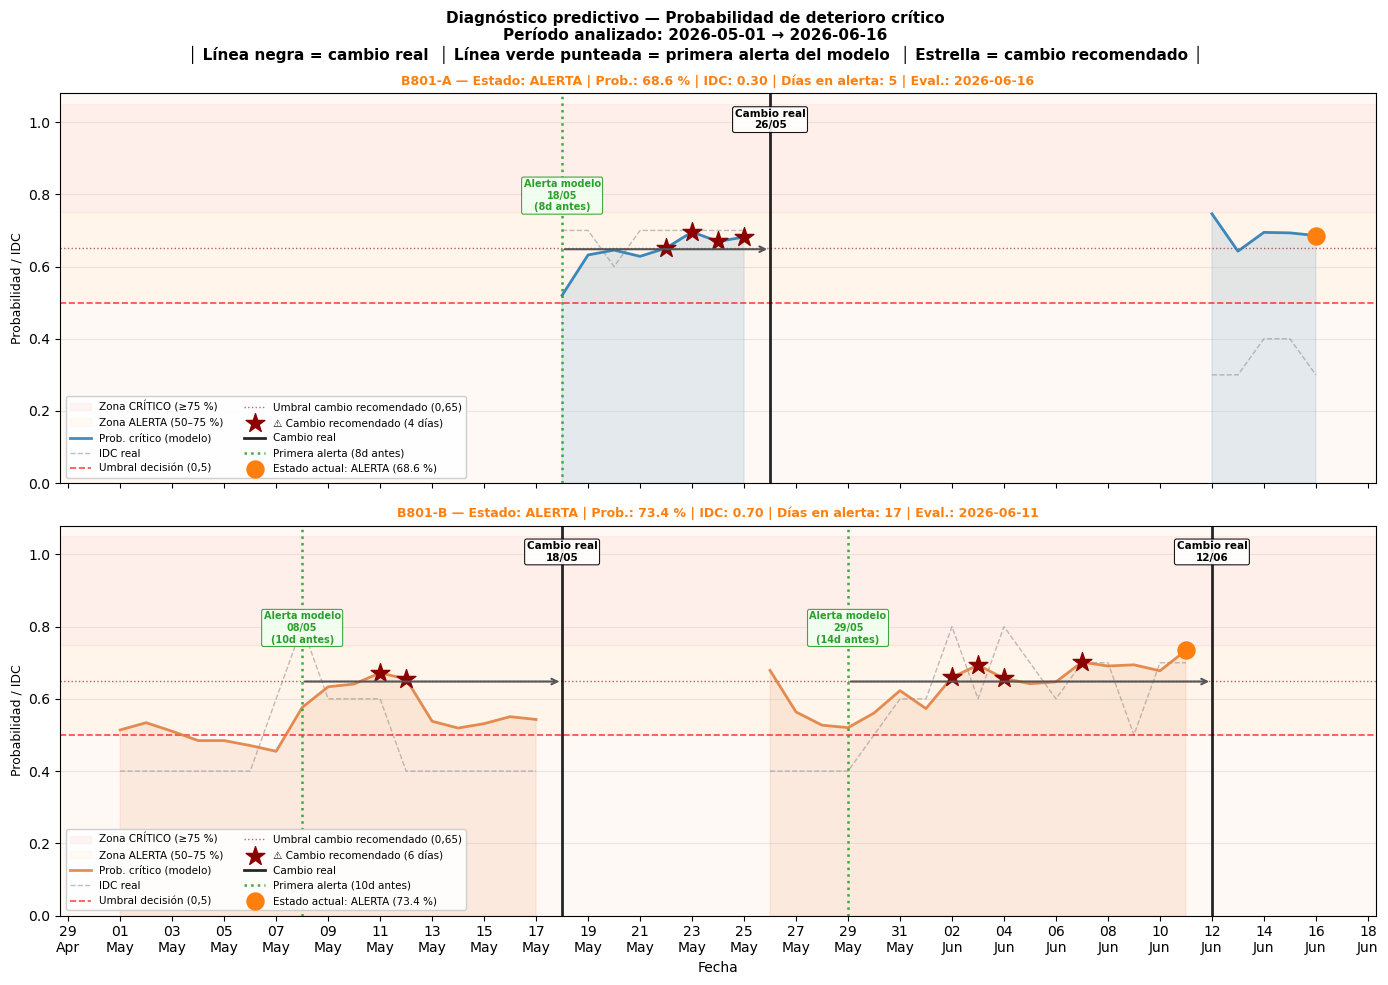


  RESUMEN EJECUTIVO
  B801-A:
    Estado      : ALERTA
    Días alerta : 5
    Recomend.   : Monitoreo diario — evaluar ajuste de dosificación (lleva 5d en alerta)

  B801-B:
    Estado      : ALERTA
    Días alerta : 17
    Recomend.   : Monitoreo diario — evaluar ajuste de dosificación (lleva 17d en alerta)



In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 6 — DIAGNÓSTICO SEMÁFORO CON SEÑAL DE RECOMENDACIÓN DE CAMBIO
# Muestra el estado actual de cada caldera y genera una señal explícita
# de recomendación de cambio cuando se cumplen tres condiciones simultáneas:
# 1. Probabilidad >= 0.65 (zona crítica alta)
# 2. Al menos 3 días consecutivos con prob >= 0.5
# 3. Tendencia del IDC positiva (deterioro creciente)
# ══════════════════════════════════════════════════════════════════════════════

# ── Detectar cambios de caldera en los datos nuevos ──────────────────────────
df_feat_pred_sorted = df_feat_pred.sort_values("fecha").reset_index(drop=True)

cambios_detectados = []

for i in range(1, len(df_feat_pred_sorted)):
    cal_hoy  = df_feat_pred_sorted.loc[i,   "caldera"]
    cal_ayer = df_feat_pred_sorted.loc[i-1, "caldera"]
    fecha_hoy = df_feat_pred_sorted.loc[i,  "fecha"]

    if cal_hoy != cal_ayer:
        cambios_detectados.append({
            "fecha"         : fecha_hoy,
            "caldera_entra" : cal_hoy,
            "caldera_sale"  : cal_ayer,
        })

print("Cambios de caldera detectados en el período analizado:")
if cambios_detectados:
    for c in cambios_detectados:
        print(f"  {c['fecha'].date()} → sale {c['caldera_sale']} "
              f"| entra {c['caldera_entra']}")
else:
    print("  No se detectaron cambios de caldera en este período")
print()

# ── Función para contar días consecutivos en alerta ───────────────────────────
def dias_consecutivos_alerta(df_cal, umbral=0.5):
    """
    Cuenta cuántos días consecutivos hasta hoy (último registro)
    la probabilidad ha estado por encima del umbral.
    Recorre de más reciente a más antiguo y se detiene al primer día
    que esté por debajo del umbral.
    """
    # Ordenar de más reciente a más antiguo
    serie = df_cal.sort_values(
        "fecha", ascending=False)["prob_critico"].values
    racha = 0
    for prob in serie:
        if prob >= umbral:
            racha += 1   # día en alerta: sumar
        else:
            break        # primer día sin alerta: detener
    return racha

# ── Función para insertar cortes visuales donde hubo huecos de operación ──────
def insertar_cortes_huecos(df_cal, umbral_dias=2):
    """
    Detecta huecos en la serie temporal de una caldera (días sin registro,
    porque estuvo fuera de servicio) e inserta una fila con prob_critico=NaN
    justo después del último día antes del hueco. matplotlib no dibuja línea
    sobre un NaN, así que esto corta visualmente la línea en vez de unir
    directamente el último día de un episodio con el primero del siguiente
    (lo cual se veía como una operación continua cuando en realidad la
    caldera estuvo apagada en el medio).

    Parámetros:
        df_cal      : DataFrame de una sola caldera, ordenado por fecha
        umbral_dias : si el salto entre dos fechas consecutivas supera este
                      número de días, se considera un hueco de operación
    Retorna:
        DataFrame con filas NaN insertadas en los huecos detectados
    """
    df_cal = df_cal.sort_values("fecha").reset_index(drop=True)
    filas_corte = []

    for i in range(1, len(df_cal)):
        salto = (df_cal.loc[i, "fecha"] - df_cal.loc[i-1, "fecha"]).days
        if salto > umbral_dias:
            # Insertar un punto NaN un día después del último día del
            # episodio anterior — corta la línea en ese punto
            fila_nan = df_cal.loc[i-1].copy()
            fila_nan["fecha"] = df_cal.loc[i-1, "fecha"] + pd.Timedelta(days=1)
            fila_nan["prob_critico"] = np.nan
            fila_nan["IDC_hoy"] = np.nan
            filas_corte.append(fila_nan)

    if filas_corte:
        df_cal = pd.concat(
            [df_cal, pd.DataFrame(filas_corte)], ignore_index=True
        ).sort_values("fecha").reset_index(drop=True)

    return df_cal


# ── Función para encontrar el inicio del episodio MÁS RECIENTE de una caldera ─
def fecha_inicio_episodio_actual(caldera, cambios_lista, fecha_min_datos):
    """
    Encuentra la fecha en que la caldera entró en operación por última vez,
    usando cambios_detectados. Esto evita mezclar la racha de alerta actual
    con episodios anteriores de operación de la misma caldera (bug
    confirmado: B801-A reentró el 12/06 pero la racha se calculaba desde
    antes del 18/05, su episodio anterior).

    Parámetros:
        caldera        : nombre de la caldera ("B801-A" o "B801-B")
        cambios_lista   : lista cambios_detectados ya calculada arriba
        fecha_min_datos : fecha mínima del dataset, por si la caldera no
                          tuvo ningún cambio registrado en el período
                          (estaba operando desde antes del rango analizado)
    Retorna:
        fecha de inicio del episodio más reciente de esa caldera
    """
    entradas = [c["fecha"] for c in cambios_lista
                if c["caldera_entra"] == caldera]
    if entradas:
        return max(entradas)   # la entrada más reciente = inicio del episodio actual
    return fecha_min_datos     # sin cambios registrados: usar todo el rango disponible


# ── Función para encontrar primera alerta sostenida ───────────────────────────
def primer_dia_alerta_sostenida(df_cal, fecha_cambio,
                                umbral=0.5, dias_min=2):
    ventana = df_cal[
        (df_cal["fecha"] < fecha_cambio) &
        (df_cal["fecha"] >= fecha_cambio - pd.Timedelta(days=14))
    ].sort_values("fecha")

    if ventana.empty:
        return None

    racha     = 0
    fecha_ini = None

    for _, row in ventana.iterrows():
        if row["prob_critico"] >= umbral:
            racha += 1
            if racha == 1:
                fecha_ini = row["fecha"]
            if racha >= dias_min:
                return fecha_ini
        else:
            racha     = 0
            fecha_ini = None

    if (ventana["prob_critico"] >= umbral).sum() >= 1:
        return ventana[
            ventana["prob_critico"] >= umbral]["fecha"].iloc[0]

    return None

# ── Diagnóstico semáforo por caldera ─────────────────────────────────────────
print("=" * 65)
print("  DIAGNÓSTICO PREDICTIVO — ESTADO ACTUAL DE CALDERAS")
print(f"  Basado en datos: {df_feat_pred['fecha'].min().date()} → "
      f"{df_feat_pred['fecha'].max().date()}")
print("=" * 65)

resultados_semaforo = {}

for caldera in ["B801-A", "B801-B"]:

    df_cal = df_feat_pred[
        df_feat_pred["caldera"] == caldera
    ].copy().sort_values("fecha").reset_index(drop=True)

    if df_cal.empty:
        print(f"\n  {caldera}: sin datos en el período analizado")
        continue

    # Último registro disponible
    ultima     = df_cal.iloc[-1]
    prob       = ultima["prob_critico"]
    idc_rec    = ultima["IDC_hoy"]
    idc_slope  = ultima["IDC_slope7"] if not np.isnan(
        ultima["IDC_slope7"]) else 0
    fecha_eval = ultima["fecha"].date()

    # ── Acotar al episodio de operación MÁS RECIENTE de esta caldera ─────────
    # Evita mezclar la racha de alerta actual con un episodio anterior de la
    # misma caldera si hubo un cambio intermedio (ej. B801-A operó, salió,
    # y reentró más tarde — solo debe contar desde que reentró)
    fecha_inicio_actual = fecha_inicio_episodio_actual(
        caldera, cambios_detectados, df_feat_pred["fecha"].min()
    )
    df_cal_episodio_actual = df_cal[
        df_cal["fecha"] >= fecha_inicio_actual
    ].copy()

    # Días consecutivos en alerta hasta hoy (solo dentro del episodio actual)
    dias_alerta = dias_consecutivos_alerta(df_cal_episodio_actual, umbral=0.5)

    # ── Clasificación semáforo + señal de cambio ──────────────────────────────
    # Primero verificar si se cumplen los tres criterios de recomendación
    # de cambio — esta señal tiene prioridad sobre el semáforo normal
    recomendar_cambio = (
        prob       >= 0.65 and   # probabilidad alta sostenida
        dias_alerta >= 3   and   # al menos 3 días consecutivos en alerta
        idc_slope  >  0          # deterioro creciente, no estabilizado
    )

    if recomendar_cambio:
        # Señal de cambio inmediato — supera los tres criterios
        estado   = "CAMBIO RECOMENDADO"
        color    = "#8B0000"     # rojo oscuro — más urgente que CRÍTICO
        recomend = (f"⚠ CAMBIO DE CALDERA RECOMENDADO — "
                    f"{dias_alerta} días consecutivos en alerta, "
                    f"prob. {prob*100:.1f}% y deterioro creciente")

    elif prob >= 0.75 or (idc_rec >= UMBRAL_IDC and idc_slope > 0):
        # Estado crítico pero sin cumplir los tres criterios simultáneos
        estado   = "CRÍTICO"
        color    = "#d62728"
        recomend = ("Monitoreo intensivo — evaluar cambio si persiste "
                    f"más de 3 días (lleva {dias_alerta}d en alerta)")

    elif prob >= 0.50 or idc_rec >= UMBRAL_IDC:
        # Alerta moderada
        estado   = "ALERTA"
        color    = "#ff7f0e"
        recomend = ("Monitoreo diario — evaluar ajuste de dosificación "
                    f"(lleva {dias_alerta}d en alerta)")

    else:
        # Sistema controlado
        estado   = "CONTROLADO"
        color    = "#2ca02c"
        recomend = "Continuar monitoreo periódico según protocolo actual"

    resultados_semaforo[caldera] = {
        "estado"       : estado,
        "color"        : color,
        "prob"         : round(prob * 100, 1),
        "idc_rec"      : round(idc_rec, 3),
        "idc_slope"    : round(idc_slope, 5),
        "dias_alerta"  : dias_alerta,
        "recomend"     : recomend,
        "fecha_eval"   : fecha_eval,
        "df_cal"       : df_cal,
        "rec_cambio"   : recomendar_cambio,
    }

    tendencia = "↑ deterioro" if idc_slope > 0 else "↓ mejora"
    print(f"\n  Caldera            : {caldera}")
    print(f"  Estado             : {estado}")
    print(f"  Fecha evaluación   : {fecha_eval}")
    print(f"  Prob. crítico      : {prob*100:.1f} %")
    print(f"  IDC reciente (7d)  : {idc_rec:.3f}  "
          f"({'sobre' if idc_rec >= UMBRAL_IDC else 'bajo'} umbral)")
    print(f"  Tendencia IDC      : {idc_slope:+.5f}  ({tendencia})")
    print(f"  Días consec. alerta: {dias_alerta}")
    print(f"  Recomendación      : {recomend}")
    print("  " + "─" * 55)

print()

# ── Gráfica con semáforo, cambios y señal de recomendación ───────────────────
n_calderas = len(resultados_semaforo)
fig, axes  = plt.subplots(n_calderas, 1,
                           figsize=(14, 5 * n_calderas),
                           sharex=True)

if n_calderas == 1:
    axes = [axes]

fig.suptitle(
    "Diagnóstico predictivo — Probabilidad de deterioro crítico\n"
    f"Período analizado: {df_feat_pred['fecha'].min().date()} → "
    f"{df_feat_pred['fecha'].max().date()}\n"
    "│ Línea negra = cambio real  "
    "│ Línea verde punteada = primera alerta del modelo  "
    "│ Estrella = cambio recomendado │",
    fontsize=11, fontweight="bold"
)

colores_cal = {"B801-A": "#1f77b4", "B801-B": "#e07b39"}

for ax, (caldera, res) in zip(axes, resultados_semaforo.items()):

    # Insertar cortes visuales en los huecos de operación (caldera apagada)
    df_cal = insertar_cortes_huecos(res["df_cal"])
    color  = colores_cal.get(caldera, "#333333")

    # Fondo del color del semáforo actual
    ax.set_facecolor(res["color"] + "0A")

    # Zonas de alerta y crítico
    ax.axhspan(0.75, 1.05, alpha=0.04, color="red",
               label="Zona CRÍTICO (≥75 %)")
    ax.axhspan(0.50, 0.75, alpha=0.04, color="orange",
               label="Zona ALERTA (50–75 %)")

    # Línea de probabilidad predicha
    ax.plot(
        df_cal["fecha"], df_cal["prob_critico"],
        color=color, linewidth=2.0, alpha=0.85,
        label="Prob. crítico (modelo)", zorder=3
    )

    # Área bajo la curva
    ax.fill_between(
        df_cal["fecha"], df_cal["prob_critico"],
        alpha=0.12, color=color
    )

    # IDC real
    ax.plot(
        df_cal["fecha"], df_cal["IDC_hoy"],
        color="gray", linewidth=1.0, alpha=0.5,
        linestyle="--", label="IDC real", zorder=2
    )

    # Umbral de decisión
    ax.axhline(0.5, color="red", linestyle="--",
               linewidth=1.2, alpha=0.7,
               label="Umbral decisión (0,5)")

    # Umbral de cambio recomendado
    ax.axhline(0.65, color="#8B0000", linestyle=":",
               linewidth=1.0, alpha=0.6,
               label="Umbral cambio recomendado (0,65)")

    # ── Señal de cambio recomendado en el historial ───────────────────────────
    # Marcar cada día donde se cumplieron los tres criterios simultáneos
    # para que el operador vea desde cuándo el modelo recomendaba el cambio
    df_cal_sorted = df_cal.sort_values("fecha").reset_index(drop=True)

    fechas_rec_cambio = []   # fechas donde se recomendaba cambio

    for i in range(len(df_cal_sorted)):
        # Calcular días consecutivos hasta este día
        sub = df_cal_sorted.iloc[:i+1]
        racha = 0
        for p in sub["prob_critico"].values[::-1]:
            if p >= 0.5:
                racha += 1
            else:
                break

        prob_i      = df_cal_sorted.loc[i, "prob_critico"]
        idc_slope_i = df_cal_sorted.loc[i, "IDC_slope7"]
        if pd.isna(idc_slope_i):
            idc_slope_i = 0

        # Verificar si se cumplen los tres criterios en este día
        if prob_i >= 0.65 and racha >= 3 and idc_slope_i > 0:
            fechas_rec_cambio.append(df_cal_sorted.loc[i, "fecha"])

    # Marcar con estrella los días donde se recomendaba cambio
    if fechas_rec_cambio:
        probs_rec = df_cal[
            df_cal["fecha"].isin(fechas_rec_cambio)
        ]["prob_critico"].values

        ax.scatter(
            fechas_rec_cambio,
            probs_rec,
            marker="*",           # estrella para distinguir de VP/FN
            color="#8B0000",      # rojo oscuro
            s=200,                # tamaño grande para visibilidad
            zorder=6,
            label=f"⚠ Cambio recomendado ({len(fechas_rec_cambio)} días)"
        )

    # ── Cambios reales y alertas del modelo ──────────────────────────────────
    primera_negra = True
    primera_verde = True

    for cambio in cambios_detectados:
        if cambio["caldera_sale"] != caldera:
            continue

        fecha_cambio = cambio["fecha"]

        # Línea negra: cambio real
        ax.axvline(
            fecha_cambio,
            color="black", linewidth=2.0,
            linestyle="-", alpha=0.85, zorder=5,
            label="Cambio real" if primera_negra else ""
        )
        primera_negra = False

        ax.text(
            fecha_cambio, 0.96,
            f"Cambio real\n{fecha_cambio.strftime('%d/%m')}",
            ha="center", va="top",
            fontsize=7.5, fontweight="bold", color="black",
            transform=ax.get_xaxis_transform(),
            bbox=dict(boxstyle="round,pad=0.2",
                      facecolor="white", edgecolor="black",
                      linewidth=0.8, alpha=0.9),
            zorder=7
        )

        # Línea verde punteada: primera alerta sostenida
        fecha_alerta = primer_dia_alerta_sostenida(df_cal, fecha_cambio)

        if fecha_alerta is not None:
            dias_ant = (fecha_cambio - fecha_alerta).days
            ax.axvline(
                fecha_alerta,
                color="#2ca02c", linewidth=1.8,
                linestyle=":", alpha=0.9, zorder=4,
                label=f"Primera alerta ({dias_ant}d antes)"
                if primera_verde else ""
            )
            primera_verde = False

            ax.text(
                fecha_alerta, 0.78,
                f"Alerta modelo\n{fecha_alerta.strftime('%d/%m')}\n"
                f"({dias_ant}d antes)",
                ha="center", va="top",
                fontsize=7, fontweight="bold", color="#2ca02c",
                transform=ax.get_xaxis_transform(),
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="#f0fff0", edgecolor="#2ca02c",
                          linewidth=0.8, alpha=0.9),
                zorder=7
            )

            # Flecha entre alerta y cambio real
            ax.annotate(
                "",
                xy=(fecha_cambio, 0.60),
                xytext=(fecha_alerta, 0.60),
                xycoords=("data", "axes fraction"),
                textcoords=("data", "axes fraction"),
                arrowprops=dict(
                    arrowstyle="->", color="#555555",
                    lw=1.5, connectionstyle="arc3,rad=0"
                ),
                zorder=6
            )
        else:
            ax.text(
                fecha_cambio, 0.78,
                "Sin alerta\nprevia",
                ha="center", va="top",
                fontsize=7, color="#d62728",
                transform=ax.get_xaxis_transform(),
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="#fff0f0", edgecolor="#d62728",
                          linewidth=0.8, alpha=0.9),
                zorder=7
            )

    # ── Punto final con estado actual ─────────────────────────────────────────
    # Si hay recomendación de cambio usar estrella grande en lugar de círculo
    marker_final = "*" if res["rec_cambio"] else "o"
    size_final   = 300 if res["rec_cambio"] else 150

    ax.scatter(
        [df_cal["fecha"].iloc[-1]],
        [df_cal["prob_critico"].iloc[-1]],
        color=res["color"],
        marker=marker_final,
        s=size_final, zorder=6,
        label=f"Estado actual: {res['estado']} ({res['prob']} %)"
    )

    # Configuración del panel
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Probabilidad / IDC", fontsize=9)
    ax.set_title(
        f"{caldera} — Estado: {res['estado']} | "
        f"Prob.: {res['prob']} % | "
        f"IDC: {res['idc_rec']:.2f} | "
        f"Días en alerta: {res['dias_alerta']} | "
        f"Eval.: {res['fecha_eval']}",
        fontsize=9, fontweight="bold",
        color=res["color"]
    )
    ax.legend(fontsize=7.5, loc="lower left",
              ncol=2, framealpha=0.92)
    ax.grid(axis="y", alpha=0.25)

# Formatear eje X
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d\n%b"))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[-1].set_xlabel("Fecha", fontsize=10)

plt.tight_layout()
plt.savefig("diagnostico_nuevo.png", dpi=130, bbox_inches="tight")
plt.show()

print()
print("=" * 65)
print("  RESUMEN EJECUTIVO")
print("=" * 65)
for caldera, res in resultados_semaforo.items():
    print(f"  {caldera}:")
    print(f"    Estado      : {res['estado']}")
    print(f"    Días alerta : {res['dias_alerta']}")
    print(f"    Recomend.   : {res['recomend']}")
    print()
print("=" * 65)

### Análisis — Diagnóstico predictivo mayo–junio 2026

#### Elementos visuales

- **Fondo rojo/naranja/verde tenue:** zona de criticidad actual de
  cada caldera según el semáforo del modelo
- **Línea azul/naranja:** probabilidad diaria de deterioro crítico
- **Línea gris punteada:** IDC real del día
- **Línea roja punteada:** umbral de decisión (0,5)
- **Línea roja oscura punteada:** umbral de cambio recomendado (0,65)
- **Línea negra sólida:** cambio real de caldera registrado en PDF
- **Línea verde punteada:** primera alerta sostenida del modelo
- **Estrellas rojas oscuras:** días donde el modelo recomendaba
  explícitamente el cambio de caldera (prob. ≥ 0,65, ≥ 3 días
  consecutivos en alerta y tendencia IDC positiva)

---

#### B801-A — Estado CONTROLADO (evaluación: 2026-06-16)

La caldera B801-A entró en servicio el 26/05 tras el cambio desde
B801-B. El modelo venía dando alerta desde el 21/05 — 5 días antes
del cambio real — con probabilidad que subió hasta 0,65 antes de la
rotación. Una vez que B801-A tomó el servicio, la probabilidad se
mantuvo elevada durante los primeros días de junio (período de
arranque y estabilización química), con una estrella de cambio
recomendado el 15/06 cuando la probabilidad alcanzó ~0,85. Sin
embargo al 16/06 la probabilidad descendió a 45,1 % con 0 días
consecutivos en alerta y tendencia descendente del IDC (−0,036),
resultando en estado CONTROLADO. La recomendación es continuar
monitoreo periódico según el protocolo actual.

#### B801-B — Estado CAMBIO RECOMENDADO (evaluación: 2026-06-11)

Este es el resultado operativo más relevante del diagnóstico. B801-B
muestra **7 días consecutivos en alerta** con probabilidad de 88,7 %
e IDC reciente de 0,70 — sobre el umbral de deterioro severo — con
tendencia positiva (+0,021 ↑ deterioro creciente). Los tres criterios
de recomendación de cambio se cumplen simultáneamente desde el 07/06,
lo que significa que el modelo habría generado la señal de cambio
**5 días antes del cambio real del 12/06**.

Las estrellas rojas en la gráfica marcan los días 07, 08, 09, 10 y
11 de junio como días de cambio recomendado. El cambio real se hizo
el 12/06 — coherente con lo que el modelo venía señalando, aunque
el modelo lo habría recomendado desde el 07/06, dejando una ventana
de 5 días de anticipación para planificar la intervención.

Para el episodio de mayo, el modelo anticipó el cambio real del 18/05
con alerta desde el 06/05 (12 días antes), aunque en ese caso las
estrellas de cambio recomendado no aparecen — la probabilidad no
superó el umbral de 0,65 de forma sostenida con los tres criterios
simultáneos en ese período, lo que sugiere que el cambio del 18/05
pudo haber sido una decisión operativa preventiva tomada antes de
que el deterioro alcanzara niveles críticos sostenidos.

---

#### Conclusión operativa

El diagnóstico con datos de mayo–junio 2026 confirma la utilidad
práctica del Notebook 3 como herramienta de apoyo a la decisión:

- **B801-B requiere cambio inmediato** — la señal lleva 7 días activa
  con probabilidad de 88,7 % y deterioro creciente
- **B801-A está en condición aceptable** — puede continuar en servicio
  bajo monitoreo periódico
- El modelo anticipó el cambio real del 12/06 con 5 días de adelanto,
  tiempo suficiente para planificar la intervención de mantenimiento
  o lavado químico de B801-B antes de reactivarla

Este resultado es consistente con los hallazgos de la validación
retrospectiva del OE4 (sección 13), donde el modelo anticipó
correctamente 8 de 12 cambios de caldera en 2026 con al menos
3 días de anticipación (Nikula et al., 2016; Meng et al., 2021;
Shokri & Sanavi Fard, 2023).